In [1]:
# Cell 1: Imports
import sys
sys.path.append('../src')
from config import *
from data.preprocess import *
from data.augmentation import *
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

print("✅ All imports successful!")


I0000 00:00:1776366924.686274  115489 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776366926.264598  115489 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776366929.485149  115489 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✅ All imports successful!


In [2]:
# Cell 2: Verify Split
print("🔍 Verifying data split...")
verify_split()


🔍 Verifying data split...

🔍 Verifying split...
✅ train: 1764 images
✅ val: 381 images
✅ test: 383 images


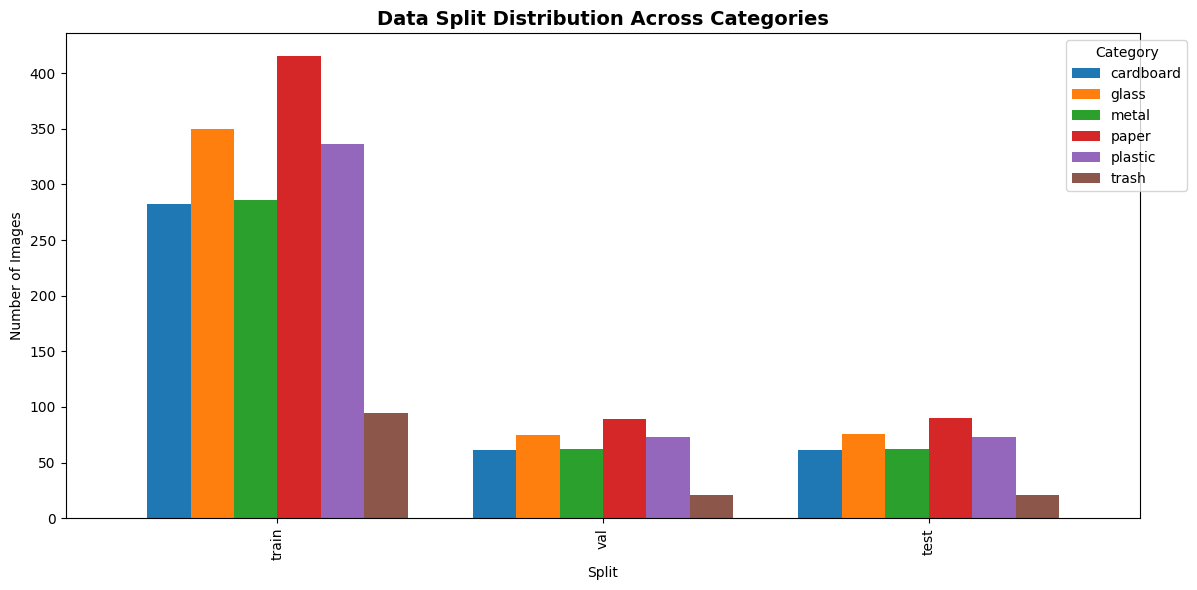

✅ Split distribution saved!


In [3]:
# Cell 3: Visualize Split Distribution
split_counts = {}
for split in ['train', 'val', 'test']:
    split_counts[split] = {}
    for category in CATEGORIES:
        path = PROCESSED_DATA_DIR / split / category   # ✅ Fixed indentation
        count = len(list(path.glob('*')))
        split_counts[split][category] = count

df = pd.DataFrame(split_counts).T
df.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Data Split Distribution Across Categories', fontsize=14, fontweight='bold')
plt.xlabel('Split')
plt.ylabel('Number of Images')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../results/plots/split_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Split distribution saved!")


In [4]:
# Cell 4: Test Data Generators
train_gen, val_gen, test_gen = create_data_generators()

print("\n✅ Data generators created successfully!")
print(f"Training batches:   {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")
print(f"Test batches:       {len(test_gen)}")


Found 1764 images belonging to 6 classes.
Found 381 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

✅ Data generators created successfully!
Training batches:   56
Validation batches: 12
Test batches:       12


✅ Visualization saved to ../results/plots/augmentation_examples.png


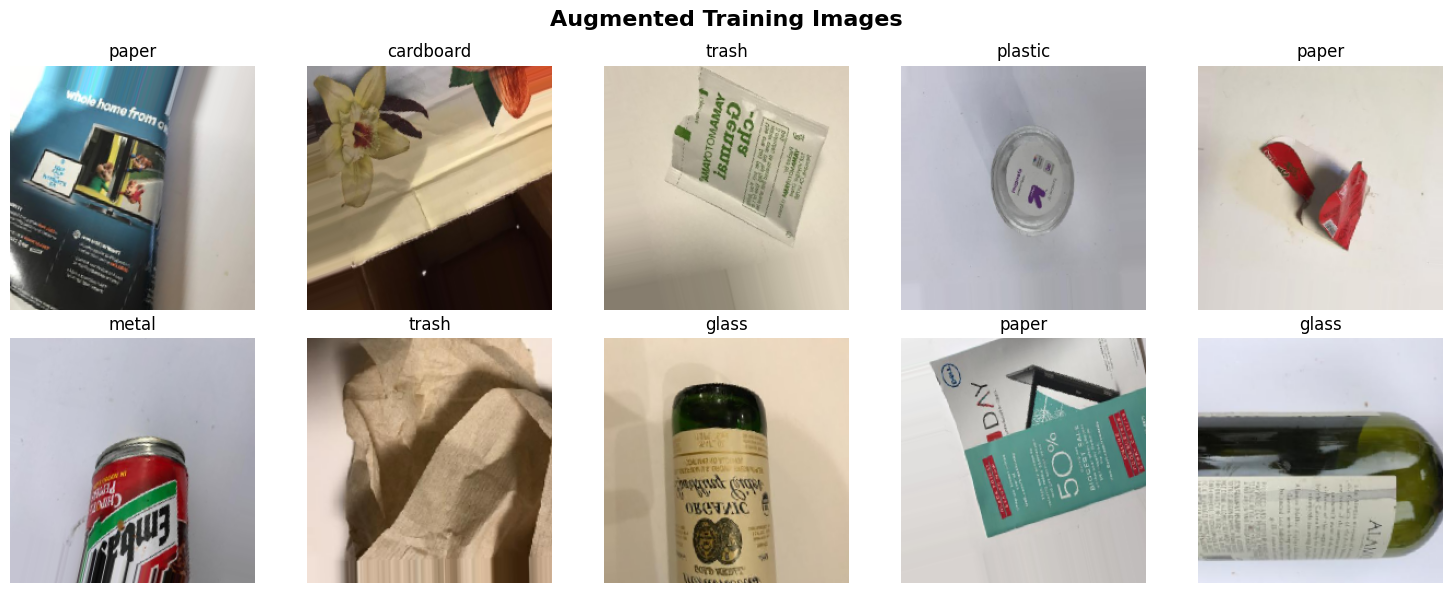

✅ Augmentation examples saved!


In [5]:
# Cell 5: Visualize Augmented Images
visualize_augmentation(train_gen, '../results/plots/augmentation_examples.png')
print("✅ Augmentation examples saved!")


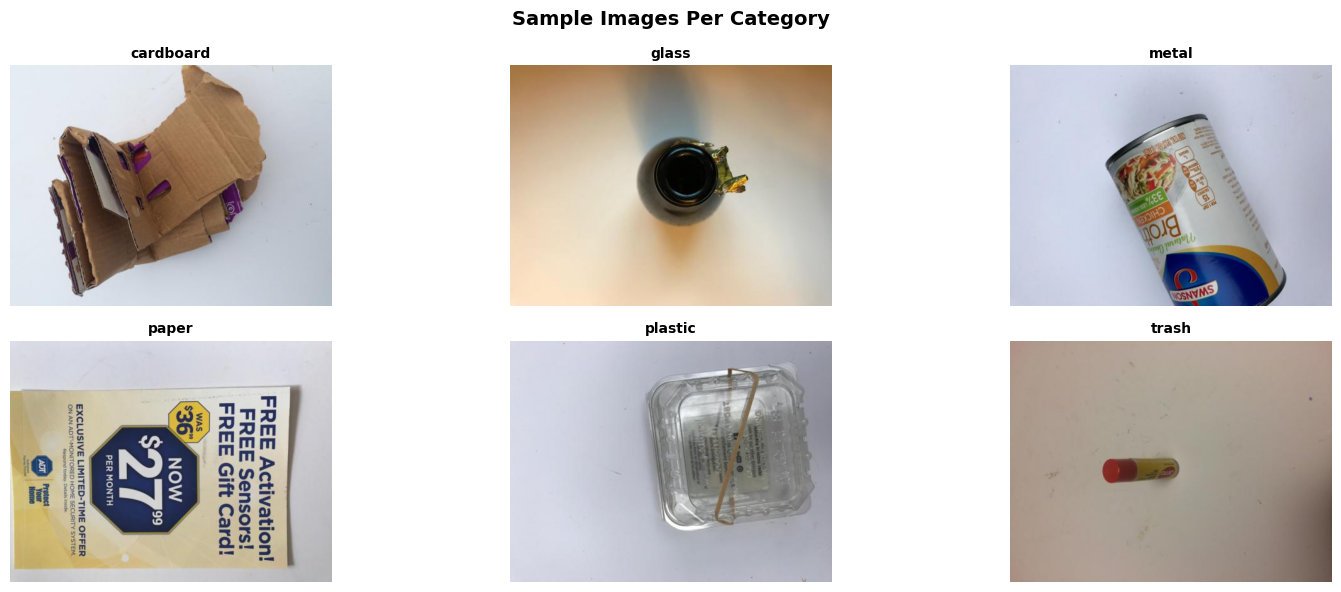

✅ Sample images saved!


In [6]:
# Cell 6: Show Sample Images Per Category 🆕
fig, axes = plt.subplots(2, len(CATEGORIES)//2, figsize=(16, 6))
axes = axes.flatten()

for idx, category in enumerate(CATEGORIES):
    img_path = list((PROCESSED_DATA_DIR / 'train' / category).glob('*'))[0]
    img = plt.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(category, fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Images Per Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/sample_images.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Sample images saved!")


In [7]:
# Cell 7: Class Balance Check 🆕
print("📊 Class Balance Summary:\n")
for split in ['train', 'val', 'test']:
    total = sum(split_counts[split].values())
    print(f"── {split.upper()} SET (Total: {total} images)")
    for cat, count in split_counts[split].items():
        bar = "█" * (count // 10)
        print(f"   {cat:<15} {count:>4} images  {bar}")
    print()



📊 Class Balance Summary:

── TRAIN SET (Total: 1764 images)
   cardboard        282 images  ████████████████████████████
   glass            350 images  ███████████████████████████████████
   metal            286 images  ████████████████████████████
   paper            415 images  █████████████████████████████████████████
   plastic          336 images  █████████████████████████████████
   trash             95 images  █████████

── VAL SET (Total: 381 images)
   cardboard         61 images  ██████
   glass             75 images  ███████
   metal             62 images  ██████
   paper             89 images  ████████
   plastic           73 images  ███████
   trash             21 images  ██

── TEST SET (Total: 383 images)
   cardboard         61 images  ██████
   glass             76 images  ███████
   metal             62 images  ██████
   paper             90 images  █████████
   plastic           73 images  ███████
   trash             21 images  ██

